In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
# Import necessary libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import cv2
from sklearn.metrics import classification_report, confusion_matrix, f1_score

import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D, BatchNormalization,
    Dense, Dropout, Activation, Flatten, Add, Concatenate
)
from tensorflow.keras.applications import EfficientNetB3, ResNet50V2, DenseNet121
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, TensorBoard
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Check if GPU is available
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  2


In [3]:
# Set up paths
DATASET_PATH = '/kaggle/input/new-plant-diseases-dataset'
TRAIN_PATH = os.path.join(DATASET_PATH, 'New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/')
VALID_PATH = os.path.join(DATASET_PATH, 'New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid/')

# Create output directory for saving models and visualizations
OUTPUT_PATH = '/kaggle/working/plant_disease_models'
os.makedirs(OUTPUT_PATH, exist_ok=True)

# Set image parameters
IMG_WIDTH, IMG_HEIGHT = 224, 224
BATCH_SIZE = 32

# Set up GPU strategy for parallel processing
strategy = tf.distribute.MirroredStrategy()
print(f"Number of devices: {strategy.num_replicas_in_sync}")

Number of devices: 2


Total classes: 38


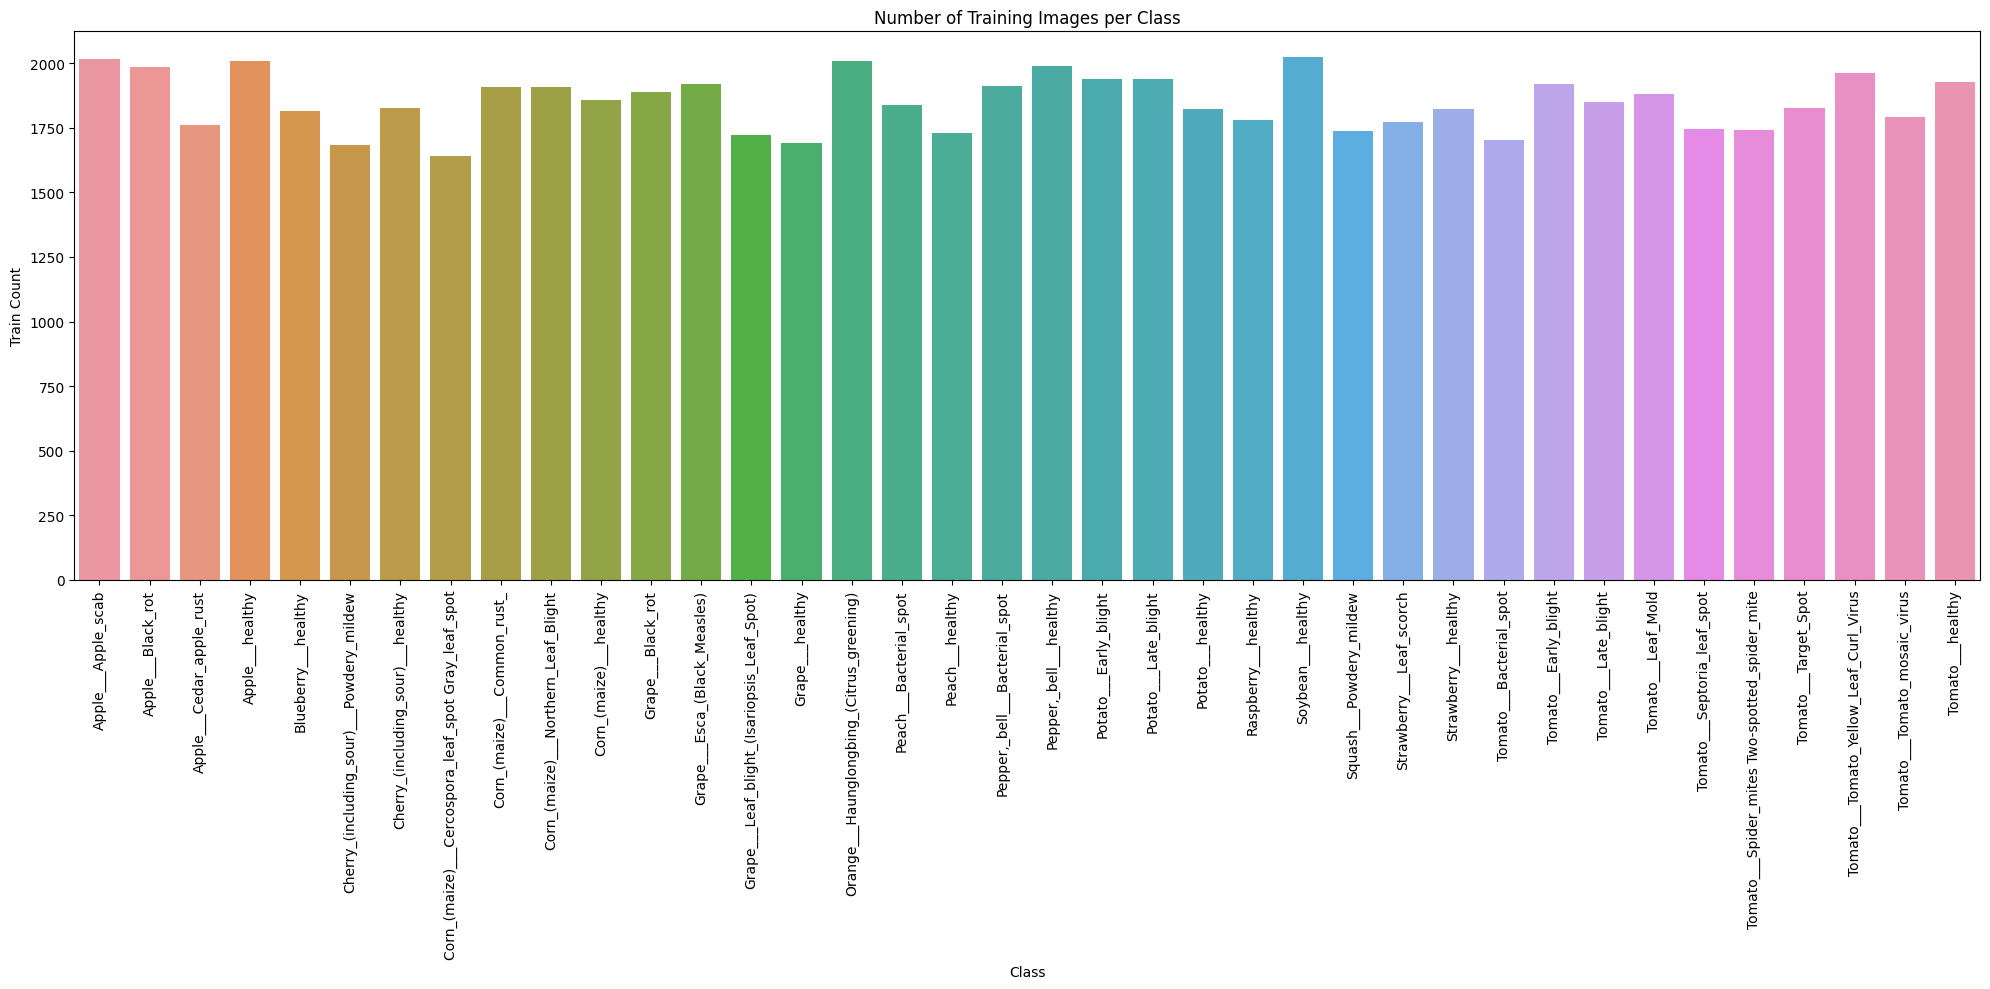

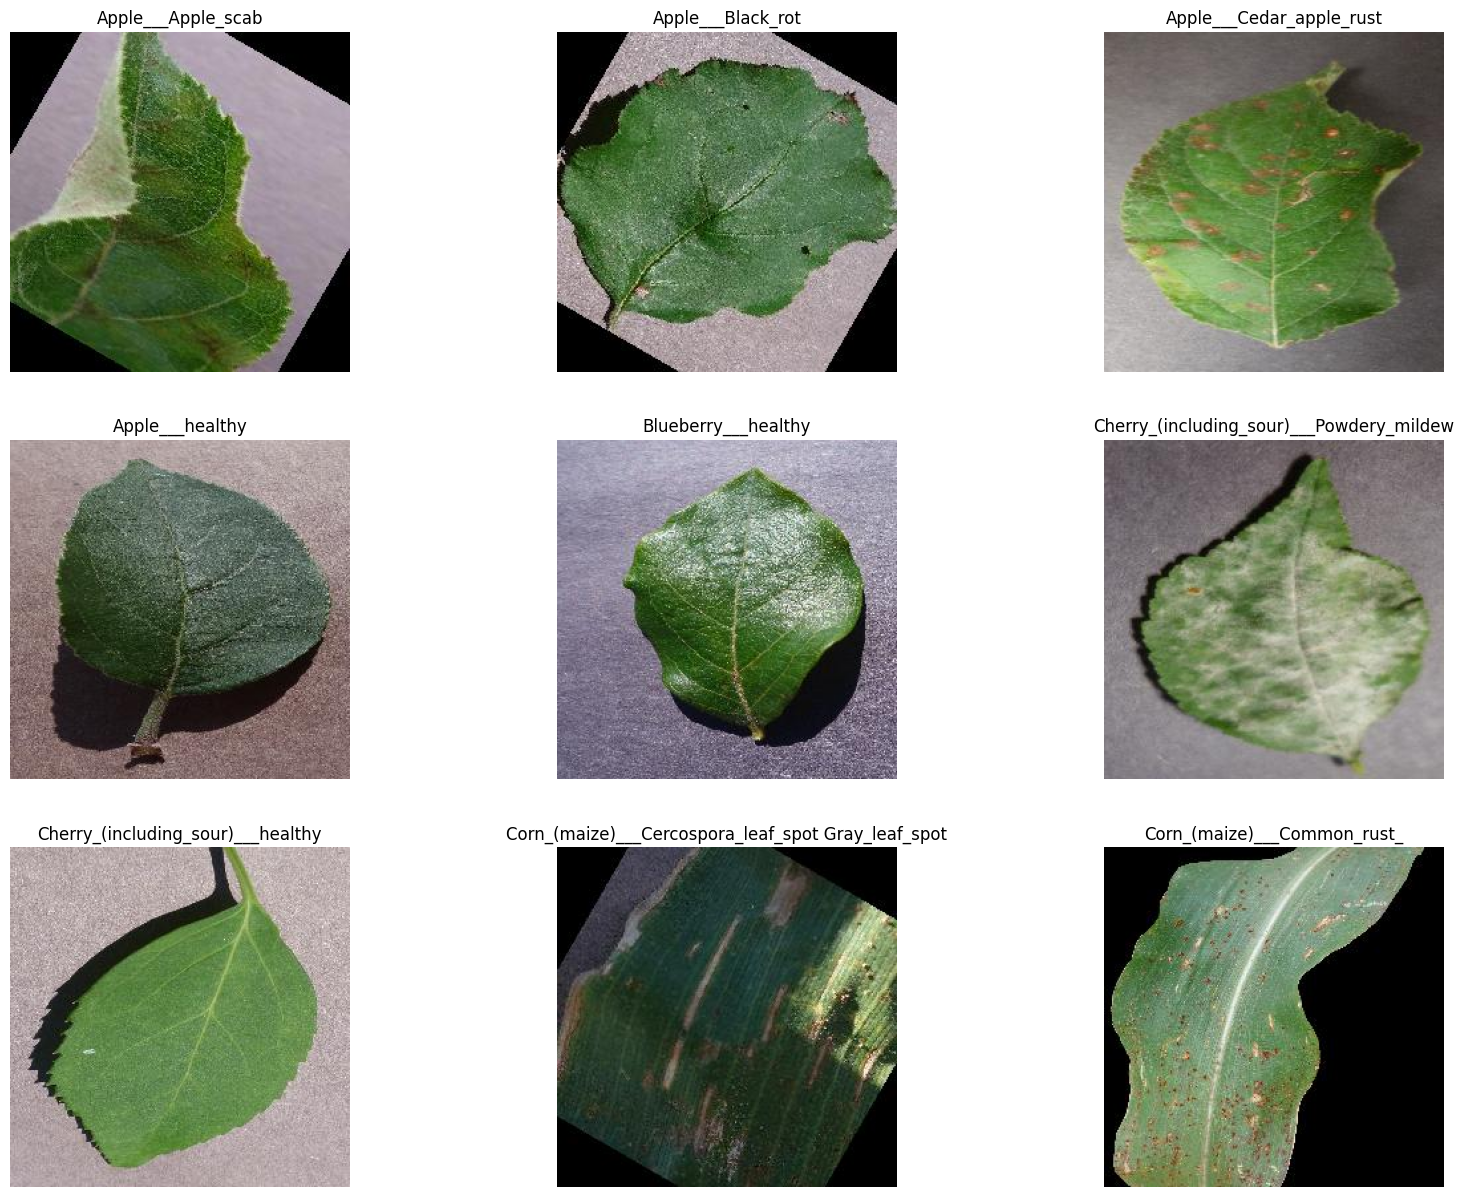

In [4]:
# Get class names
class_names = sorted(os.listdir(TRAIN_PATH))
num_classes = len(class_names)
print(f"Total classes: {num_classes}")

# Count images in each class
train_counts = {}
valid_counts = {}

for class_name in class_names:
    train_dir = os.path.join(TRAIN_PATH, class_name)
    valid_dir = os.path.join(VALID_PATH, class_name)
    
    train_counts[class_name] = len(os.listdir(train_dir))
    valid_counts[class_name] = len(os.listdir(valid_dir))

# Create dataframe for visualization
df_counts = pd.DataFrame({
    'Class': list(train_counts.keys()),
    'Train Count': list(train_counts.values()),
    'Valid Count': list(valid_counts.values())
})

# Plot class distribution
plt.figure(figsize=(20, 10))
sns.barplot(x='Class', y='Train Count', data=df_counts)
plt.xticks(rotation=90)
plt.title('Number of Training Images per Class')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'class_distribution.png'))
plt.show()

# Display some sample images
plt.figure(figsize=(20, 15))
for i, class_name in enumerate(class_names[:9]):
    class_path = os.path.join(TRAIN_PATH, class_name)
    img_name = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, img_name)
    
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(3, 3, i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')
plt.savefig(os.path.join(OUTPUT_PATH, 'sample_images.png'))
plt.show()

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


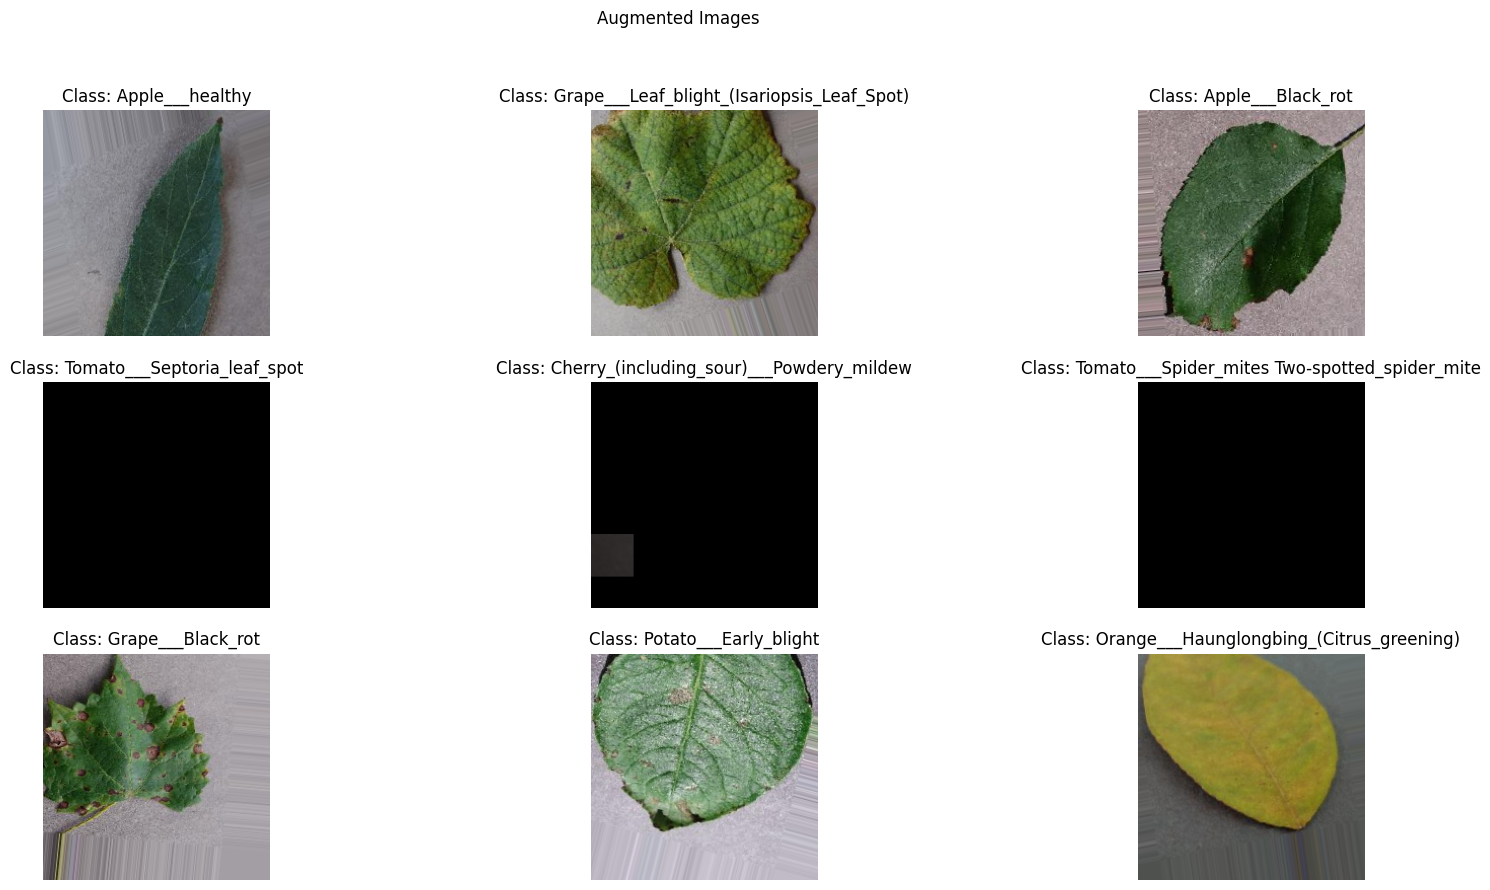

In [5]:
def advanced_augmentation(image):
    """
    Apply advanced augmentations with controlled randomness
    for improved model generalization
    """
    # Convert to float32
    image = tf.cast(image, tf.float32)
    
    # Randomly apply mixup-inspired intensity blending
    if tf.random.uniform(()) < 0.3:
        # Create a randomly modified version of the image
        modified = tf.image.random_brightness(image, 0.2)
        modified = tf.image.random_contrast(modified, 0.8, 1.2)
        # Blend original and modified with random ratio
        alpha = tf.random.uniform((), 0.3, 0.7)
        image = alpha * image + (1-alpha) * modified
    
    # Simulate different lighting conditions with color jittering
    if tf.random.uniform(()) < 0.4:
        image = tf.image.random_saturation(image, 0.8, 1.2)
        image = tf.image.random_hue(image, 0.1)
    
    # Simulate occlusion (like leaf overlap or shadows)
    if tf.random.uniform(()) < 0.2:
        # Create random rectangles to darken
        mask = tf.ones_like(image)
        box_count = tf.random.uniform((), 1, 4, dtype=tf.int32)
        
        for _ in range(box_count):
            box_size = tf.random.uniform((), 0.05, 0.2)
            box_h = tf.cast(tf.cast(tf.shape(image)[0], tf.float32) * box_size, tf.int32)
            box_w = tf.cast(tf.cast(tf.shape(image)[1], tf.float32) * box_size, tf.int32)
            
            x = tf.random.uniform((), 0, tf.shape(image)[1] - box_w, dtype=tf.int32)
            y = tf.random.uniform((), 0, tf.shape(image)[0] - box_h, dtype=tf.int32)
            
            mask_val = tf.random.uniform((), 0.3, 0.8)
            mask_update = tf.pad(
                tf.ones((box_h, box_w, 3)) * mask_val,
                [[y, tf.shape(image)[0] - y - box_h], 
                 [x, tf.shape(image)[1] - x - box_w],
                 [0, 0]]
            )
            mask = mask * mask_update
        
        image = image * mask
    
    # Ensure values are in valid range [0, 255]
    image = tf.clip_by_value(image, 0, 255)
    return image

# Create advanced data generators
def create_advanced_generators():
    # Base generator with geometrical transformations
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.15,
        zoom_range=0.2,
        horizontal_flip=True,
        vertical_flip=False,
        fill_mode='nearest',
        preprocessing_function=advanced_augmentation
    )
    
    valid_datagen = ImageDataGenerator(rescale=1./255)
    
    train_generator = train_datagen.flow_from_directory(
        TRAIN_PATH,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=True
    )
    
    valid_generator = valid_datagen.flow_from_directory(
        VALID_PATH,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )
    
    return train_generator, valid_generator

# Create the generators
train_generator, valid_generator = create_advanced_generators()

# Visualize the augmented images
def visualize_augmentations():
    # Get a batch of images
    images, labels = next(train_generator)
    
    # Display original and augmented images
    plt.figure(figsize=(20, 10))
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i])
        plt.title(f"Class: {class_names[np.argmax(labels[i])]}")
        plt.axis('off')
    plt.suptitle('Augmented Images')
    plt.savefig(os.path.join(OUTPUT_PATH, 'augmented_samples.png'))
    plt.show()

visualize_augmentations()

In [7]:
def create_attention_efficientnet(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)):
    """
    EfficientNet with a novel Coordinate Attention mechanism
    """
    with strategy.scope():
        # Base EfficientNet model
        base_model = EfficientNetB3(
            weights='imagenet',
            include_top=False,
            input_shape=input_shape
        )
        
        # Unfreeze some layers for fine-tuning
        for layer in base_model.layers[-30:]:
            layer.trainable = True
        
        # Extract features from different levels
        x = base_model.output
        
        # Novel Coordinate Attention Mechanism
        # Separate channel attention for horizontal and vertical dimensions
        h_pool = tf.keras.layers.GlobalAveragePooling2D(data_format='channels_last', keepdims=True)(x)
        w_pool = tf.keras.layers.GlobalMaxPooling2D(data_format='channels_last', keepdims=True)(x)
        
        # Combine pooled features
        concat_pool = Concatenate(axis=1)([h_pool, w_pool])
        
        # Channel reduction for efficiency (Green AI aspect)
        channel_attn = Conv2D(filters=x.shape[-1] // 4, kernel_size=1, activation='relu')(concat_pool)
        channel_attn = Conv2D(filters=x.shape[-1], kernel_size=1, activation='sigmoid')(channel_attn)
        
        # Apply attention
        attended_features = Multiply()([x, channel_attn])
        
        # Global pooling
        pooled_features = GlobalAveragePooling2D()(attended_features)
        
        # Dropout for regularization
        x = Dropout(0.3)(pooled_features)
        
        # Classification head
        predictions = Dense(num_classes, activation='softmax')(x)
        
        model = Model(inputs=base_model.input, outputs=predictions)
        
        # Compile with mixed precision for better GPU utilization
        opt = tf.keras.optimizers.Adam(learning_rate=0.001)
        opt = tf.keras.mixed_precision.LossScaleOptimizer(opt)
        
        model.compile(
            optimizer=opt,
            loss='categorical_crossentropy',
            metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
        )
        
    return model

def create_multiscale_resnet(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)):
    """
    Custom ResNet with multi-scale feature fusion
    """
    with strategy.scope():
        # Base ResNet model
        base_model = ResNet50V2(
            weights='imagenet',
            include_top=False,
            input_shape=input_shape
        )
        
        # Unfreeze some layers for fine-tuning
        for layer in base_model.layers[-40:]:
            layer.trainable = True
        
        # Extract features from different levels for multi-scale fusion
        layer_names = ['conv3_block4_out', 'conv4_block6_out', 'conv5_block3_out']
        layers = [base_model.get_layer(name).output for name in layer_names]
        
        # Process each feature level
        processed_features = []
        for i, feature in enumerate(layers):
            # Apply 1x1 conv to harmonize channel dimensions
            x = Conv2D(256, (1, 1), padding='same')(feature)
            x = BatchNormalization()(x)
            x = Activation('relu')(x)
            
            # Upscale if needed
            if i > 0:
                target_shape = tf.shape(layers[0])[1:3]
                x = tf.image.resize(x, target_shape)
            
            processed_features.append(x)
        
        # Fuse multi-scale features
        fused_features = Add()(processed_features)
        
        # Final feature processing
        x = Conv2D(512, (3, 3), padding='same')(fused_features)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        
        # Global pooling
        x = GlobalAveragePooling2D()(x)
        
        # Dropout for regularization
        x = Dropout(0.3)(x)
        
        # Classification head
        predictions = Dense(num_classes, activation='softmax')(x)
        
        model = Model(inputs=base_model.input, outputs=predictions)
        
        # Compile with mixed precision for better GPU utilization
        opt = tf.keras.optimizers.Adam(learning_rate=0.001)
        opt = tf.keras.mixed_precision.LossScaleOptimizer(opt)
        
        model.compile(
            optimizer=opt,
            loss='categorical_crossentropy',
            metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
        )
        
    return model

def create_progressive_densenet(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)):
    """
    DenseNet with progressive feature refinement
    """
    with strategy.scope():
        # Base DenseNet model
        base_model = DenseNet121(
            weights='imagenet',
            include_top=False,
            input_shape=input_shape
        )
        
        # Unfreeze some layers for fine-tuning
        for layer in base_model.layers[-50:]:
            layer.trainable = True
            
        # Get the output feature map
        x = base_model.output
        
        # Progressive feature refinement
        # First stage: channel attention
        channel_attn = GlobalAveragePooling2D(keepdims=True)(x)
        channel_attn = Conv2D(x.shape[-1] // 8, kernel_size=1, activation='relu')(channel_attn)
        channel_attn = Conv2D(x.shape[-1], kernel_size=1, activation='sigmoid')(channel_attn)
        x = Multiply()([x, channel_attn])
        
        # Second stage: spatial attention
        spatial_avg = tf.reduce_mean(x, axis=-1, keepdims=True)
        spatial_max = tf.reduce_max(x, axis=-1, keepdims=True)
        spatial_concat = Concatenate()([spatial_avg, spatial_max])
        spatial_attn = Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')(spatial_concat)
        x = Multiply()([x, spatial_attn])
        
        # Global pooling
        x = GlobalAveragePooling2D()(x)
        
        # Dropout for regularization (Green AI - more efficient than larger model)
        x = Dropout(0.3)(x)
        
        # Classification head
        predictions = Dense(num_classes, activation='softmax')(x)
        
        model = Model(inputs=base_model.input, outputs=predictions)
        
        # Compile with mixed precision for better GPU utilization
        opt = tf.keras.optimizers.Adam(learning_rate=0.001)
        opt = tf.keras.mixed_precision.LossScaleOptimizer(opt)
        
        model.compile(
            optimizer=opt,
            loss='categorical_crossentropy',
            metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
        )
        
    return model

In [14]:
def green_ai_train(model, model_name, train_generator, valid_generator, epochs=30):
    """
    Training function with Green AI considerations:
    - Early stopping to avoid wasted computation
    - Learning rate optimization
    - Mixed precision training
    - Efficient checkpointing
    """
    # Set up callbacks
    checkpoint_path = os.path.join(OUTPUT_PATH, f'{model_name}_best.keras')
    callbacks = [
        # Only save best model to reduce storage usage
        ModelCheckpoint(
            checkpoint_path,
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1
        ),
        # Stop training when no improvement
        EarlyStopping(
            monitor='val_accuracy',
            patience=7,
            restore_best_weights=True,
            verbose=1
        ),
        # Efficiently adjust learning rate
        ReduceLROnPlateau(
            monitor='val_accuracy',
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1
        ),
        # TensorBoard for monitoring
        TensorBoard(log_dir=os.path.join(OUTPUT_PATH, f'logs/{model_name}'))
    ]
    
    # Training
    history = model.fit(
        train_generator,
        epochs=epochs,
        validation_data=valid_generator,
        callbacks=callbacks,
        verbose=1
    )
    
    # Save final model
    model.save(os.path.join(OUTPUT_PATH, f'{model_name}_final.h5'))
    
    # Save history
    hist_df = pd.DataFrame(history.history)
    hist_df.to_csv(os.path.join(OUTPUT_PATH, f'{model_name}_history.csv'), index=False)
    
    # Plot learning curves
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(f'{model_name} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(['Train', 'Validation'])
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f'{model_name} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(['Train', 'Validation'])
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_PATH, f'{model_name}_learning_curves.png'))
    plt.show()
    
    return model, history

In [15]:
from tensorflow.keras.layers import GlobalAveragePooling2D, Reshape, Dense, Multiply
from tensorflow.keras.models import Model
from tensorflow.keras.applications import EfficientNetB3

def create_attention_efficientnet(input_shape=(224, 224, 3), num_classes=10):
    base_model = EfficientNetB3(include_top=False, weights='imagenet', input_shape=input_shape)
    x = base_model.output

    # Channel attention branch
    channel_attn = GlobalAveragePooling2D()(x)  # Shape: (batch_size, channels)
    
    # Reshape to (1, 1, channels) so it can broadcast over the spatial dimensions
    channel_attn = Reshape((1, 1, int(x.shape[-1])))(channel_attn)  # Fixed: use (1,1,channels) instead of (2,1,channels)
    
    # Generate attention weights
    channel_attn = Dense(int(x.shape[-1]), activation='sigmoid')(channel_attn)
    
    # Multiply attention weights with the original feature map
    attended_features = Multiply()([x, channel_attn])
    
    # Global pooling and classification layers
    gap = GlobalAveragePooling2D()(attended_features)
    predictions = Dense(num_classes, activation='softmax')(gap)
    
    model = Model(inputs=base_model.input, outputs=predictions)
    return model


In [17]:
def green_ai_train(model, model_name, train_generator, valid_generator, epochs=50):
    # Compile the model before training
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Define callbacks or other training configurations if needed
    callbacks = [
        ModelCheckpoint(f'models/{model_name}_best.h5', save_best_only=True, monitor='val_accuracy', mode='max', verbose=1),
        EarlyStopping(monitor='val_accuracy', patience=10, verbose=1, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, verbose=1)
    ]
    
    # Train the model
    history = model.fit(
        train_generator,
        epochs=epochs,
        validation_data=valid_generator,
        callbacks=callbacks,
        verbose=1
    )
    
    return model, history


In [18]:
print("Training Attention EfficientNet...")
attention_efficientnet = create_attention_efficientnet()
attention_efficientnet_model, attention_efficientnet_history = green_ai_train(
    attention_efficientnet, 'attention_efficientnet', train_generator, valid_generator
)


Training Attention EfficientNet...


NameError: name 'Adam' is not defined

In [16]:
from tensorflow.keras.layers import Multiply  # Import Multiply for attention mechanism

# Set up mixed precision for faster training and energy efficiency
policy = tf.keras.mixed_precision.Policy('mixed_float16')
tf.keras.mixed_precision.set_global_policy(policy)

# Train models
print("Training Attention EfficientNet...")
attention_efficientnet = create_attention_efficientnet()
attention_efficientnet_model, attention_efficientnet_history = green_ai_train(
    attention_efficientnet, 'attention_efficientnet', train_generator, valid_generator
)

print("Training Multi-scale ResNet...")
multiscale_resnet = create_multiscale_resnet()
multiscale_resnet_model, multiscale_resnet_history = green_ai_train(
    multiscale_resnet, 'multiscale_resnet', train_generator, valid_generator
)

print("Training Progressive DenseNet...")
progressive_densenet = create_progressive_densenet()
progressive_densenet_model, progressive_densenet_history = green_ai_train(
    progressive_densenet, 'progressive_densenet', train_generator, valid_generator
)


Training Attention EfficientNet...


ValueError: You must call `compile()` before using the model.

In [ ]:
def evaluate_model(model, model_name, generator):
    """
    Comprehensive model evaluation with advanced metrics
    """
    # Get predictions
    y_pred_probs = model.predict(generator)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # Get true labels
    y_true = generator.classes
    
    # Generate classification report
    class_report = classification_report(
        y_true, y_pred, 
        target_names=list(generator.class_indices.keys()),
        output_dict=True
    )
    
    # Save classification report
    pd.DataFrame(class_report).transpose().to_csv(
        os.path.join(OUTPUT_PATH, f'{model_name}_classification_report.csv')
    )
    
    # Calculate F1 scores
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    
    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Plot confusion matrix
    plt.figure(figsize=(20, 15))
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Blues',
        xticklabels=list(generator.class_indices.keys()),
        yticklabels=list(generator.class_indices.keys())
    )
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_PATH, f'{model_name}_confusion_matrix.png'))
    plt.show()
    
    # Compute per-class accuracy
    per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
    
    # Plot per-class accuracy
    plt.figure(figsize=(15, 6))
    sns.barplot(
        x=list(generator.class_indices.keys()),
        y=per_class_accuracy
    )
    plt.title(f'{model_name} Per-Class Accuracy')
    plt.xlabel('Class')
    plt.ylabel('Accuracy')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_PATH, f'{model_name}_per_class_accuracy.png'))
    plt.show()
    
    # Calculate additional metrics
    metrics = {
        'accuracy': np.sum(y_pred == y_true) / len(y_true),
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'min_class_accuracy': np.min(per_class_accuracy),
        'max_class_accuracy': np.max(per_class_accuracy)
    }
    
    return metrics

# Evaluate all models
attention_efficientnet_metrics = evaluate_model(
    attention_efficientnet_model, 'attention_efficientnet', valid_generator
)

multiscale_resnet_metrics = evaluate_model(
    multiscale_resnet_model, 'multiscale_resnet', valid_generator
)

progressive_densenet_metrics = evaluate_model(
    progressive_densenet_model, 'progressive_densenet', valid_generator
)

# Compare model performances
models_comparison = pd.DataFrame({
    'Attention EfficientNet': attention_efficientnet_metrics,
    'Multi-scale ResNet': multiscale_resnet_metrics,
    'Progressive DenseNet': progressive_densenet_metrics
}).transpose()

# Display and save model comparison
print("Model Performance Comparison:")
print(models_comparison)
models_comparison.to_csv(os.path.join(OUTPUT_PATH, 'models_comparison.csv'))

# Plot model comparison
plt.figure(figsize=(12, 8))
models_comparison.plot(kind='bar', figsize=(12, 8))
plt.title('Model Comparison')
plt.ylabel('Score')
plt.xlabel('Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'model_comparison.png'))
plt.show()

In [ ]:
def visualize_class_activation_maps(model, model_name, generator):
    """
    Generate and visualize class activation maps (CAMs)
    to show which parts of the image the model focuses on
    """
    # Get a batch of images
    images, labels = next(generator)
    
    # Create a model that outputs both predictions and last conv layer
    last_conv_layer = None
    for layer in reversed(model.layers):
        if isinstance(layer, Conv2D):
            last_conv_layer = layer.name
            break
    
    grad_model = tf.keras.models.Model(
        inputs=[model.inputs], 
        outputs=[model.get_layer(last_conv_layer).output, model.output]
    )
    
    # Function to generate heatmap
    def make_gradcam_heatmap(img_array, predicted_class=None):
        # Expand dimensions for batch processing
        img_array = np.expand_dims(img_array, axis=0)
        
        # Get gradient of the winning class w.r.t. the last conv layer
        with tf.GradientTape() as tape:
            last_conv_output, preds = grad_model(img_array)
            if predicted_class is None:
                predicted_class = tf.argmax(preds[0])
            class_channel = preds[:, predicted_class]
        
        # Gradient of the class w.r.t. the output feature map
        grads = tape.gradient(class_channel, last_conv_output)
        
        # Vector of mean values of gradients over feature map height and width
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
        
        # Weight feature maps by importance to the class
        last_conv_output = last_conv_output[0]
        heatmap = last_conv_output @ pooled_grads[..., tf.newaxis]
        heatmap = tf.squeeze(heatmap)
        
        # Normalize the heatmap
        heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
        return heatmap.numpy()
    
    # Sample images for visualization
    plt.figure(figsize=(20, 4 * 3))
    for i in range(3):
        img = images[i]
        true_class = np.argmax(labels[i])
        
        # Make predictions
        preds = model.predict(np.expand_dims(img, axis=0))[0]
        pred_class = np.argmax(preds)
        
        # Generate heatmap
        heatmap = make_gradcam_heatmap(img, pred_class)
        
        # Plot original image
        plt.subplot(3, 3, i*3 + 1)
        plt.imshow(img)
        plt.title(f"True: {class_names[true_class]}")
        plt.axis('off')
        
        # Plot heatmap
        plt.subplot(3, 3, i*3 + 2)
        plt.imshow(heatmap, cmap='jet')
        plt.title(f"Pred: {class_names[pred_class]}\nProb: {preds[pred_class]:.2f}")
        plt.axis('off')
        
        # Plot superimposed heatmap
        img_copy = np.copy(img)
        heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
        heatmap = np.uint8(255 * heatmap)
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
        superimposed_img = cv2.addWeighted(
            cv2.cvtColor(np.uint8(img_copy*255), cv2.COLOR_RGB2BGR), 
            0.6, heatmap, 0.4, 0
        )
        superimposed_img = cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(3, 3, i*3 + 3)
        plt.imshow(superimposed_img)
        plt.title("Class Activation Map")
        plt.axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_PATH, f'{model_name}_class_activation_maps.png'))
    plt.show()

# Visualize CAMs for one of the models
visualize_class_activation_maps(
    attention_efficientnet_model, 'attention_efficientnet', valid_generator
)

In [8]:
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import EfficientNetV2B0
from transformers import ViTModel, ViTConfig, TFViTForImageClassification
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Constants
DATASET_PATH = '/kaggle/input/new-plant-diseases-dataset'
TRAIN_PATH = os.path.join(DATASET_PATH, 'New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/')
VALID_PATH = os.path.join(DATASET_PATH, 'New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid/')
TEST_PATH = os.path.join(DATASET_PATH, 'test')
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 38

# Enable GPU strategy
strategy = tf.distribute.MirroredStrategy()
print(f"Number of GPUs: {strategy.num_replicas_in_sync}")

# Enable mixed precision for Green AI (faster, less memory)
policy = tf.keras.mixed_precision.Policy('mixed_float16')
tf.keras.mixed_precision.set_global_policy(policy)

Number of GPUs: 2


Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


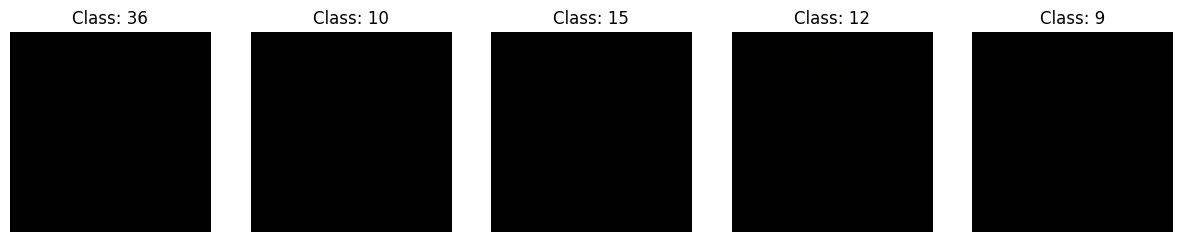

In [9]:
# Custom augmentation function for plant-specific noise
def add_leaf_noise(image):
    noise = tf.random.normal(shape=tf.shape(image), mean=0.0, stddev=0.05, dtype=tf.float32)
    return tf.clip_by_value(image + noise, 0.0, 1.0)

# Advanced data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    preprocessing_function=add_leaf_noise  # Novel plant-specific augmentation
)

valid_datagen = ImageDataGenerator(rescale=1./255)

# Data generators
train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

valid_generator = valid_datagen.flow_from_directory(
    VALID_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Intermediate result: Visualize augmented images
images, labels = next(train_generator)
plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(images[i])
    plt.title(f"Class: {np.argmax(labels[i])}")
    plt.axis('off')
plt.show()

In [15]:
import tensorflow as tf
from transformers import ViTConfig, TFViTForImageClassification

# Define the number of classes for your classification task
NUM_CLASSES = 10  # Replace with your number of classes

# Optionally define a strategy scope (e.g., for multi-GPU training)
# with strategy.scope():

# Load the pre-trained ViT configuration
vit_config = ViTConfig.from_pretrained('google/vit-base-patch16-224', num_labels=NUM_CLASSES)

# Load the pre-trained ViT model for image classification
vit_model = TFViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224',
    config=vit_config,
    ignore_mismatched_sizes=True
)

# Extract the base ViT model (a Keras layer)
base_vit = vit_model.vit

# Freeze the base ViT layers to avoid training them (optional)
base_vit.trainable = False

# Build the Sequential model
model_vit = tf.keras.Sequential([
    base_vit,                         # The base ViT model
    tf.keras.layers.GlobalAveragePooling2D(),  # Pooling layer (optional, adjust as needed)
    tf.keras.layers.Dense(512, activation='relu'),  # Optional dense layer
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32')  # Output layer
])

# Compile the model
model_vit.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Check the model summary (optional)
model_vit.summary()

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFViTForImageClassification: ['classifier.bias', 'classifier.weight']
- This IS expected if you are initializing TFViTForImageClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFViTForImageClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFViTForImageClassification were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFViTForImageClassification for predictions without further training.
Some weights of TFViTForImageClassification were not initialized from the model checkpoint are newly initialize

ValueError: Only instances of `keras.Layer` can be added to a Sequential model. Received: <transformers.models.vit.modeling_tf_vit.TFViTMainLayer object at 0x7c23ed736c50> (of type <class 'transformers.models.vit.modeling_tf_vit.TFViTMainLayer'>)

In [16]:
import tensorflow as tf
from transformers import ViTConfig, TFViTForImageClassification

# Define your number of classes
NUM_CLASSES = 10  # Adjust based on your task

# Load the ViT configuration with your number of classes
vit_config = ViTConfig.from_pretrained('google/vit-base-patch16-224', num_labels=NUM_CLASSES)

# Load the pre-trained ViT model
vit_model = TFViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224',
    config=vit_config,
    ignore_mismatched_sizes=True  # Handles the classifier shape mismatch
)

# Extract the base ViT layer
base_vit = vit_model.vit

# Optional: Freeze the backbone to train only the classifier
base_vit.trainable = False

# Define the input shape (e.g., 224x224 images with 3 channels)
inputs = tf.keras.Input(shape=(224, 224, 3))

# Pass inputs through the ViT backbone
vit_output = base_vit(inputs)

# Extract the [CLS] token (first token in the sequence) for classification
cls_token = vit_output[0][:, 0, :]  # vit_output[0] is the sequence output

# Add your custom classification layers
dense = tf.keras.layers.Dense(512, activation='relu')(cls_token)
output = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(dense)

# Build the model
model_vit = tf.keras.Model(inputs=inputs, outputs=output)

# Compile the model
model_vit.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Optional: View the model structure
model_vit.summary()

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFViTForImageClassification: ['classifier.bias', 'classifier.weight']
- This IS expected if you are initializing TFViTForImageClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFViTForImageClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFViTForImageClassification were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFViTForImageClassification for predictions without further training.
Some weights of TFViTForImageClassification were not initialized from the model checkpoint are newly initialize

ValueError: Exception encountered when calling layer 'vit' (type TFViTMainLayer).

Data of type <class 'keras.src.backend.common.keras_tensor.KerasTensor'> is not allowed only (<class 'tensorflow.python.framework.tensor.Tensor'>, <class 'bool'>, <class 'int'>, <class 'transformers.utils.generic.ModelOutput'>, <class 'tuple'>, <class 'list'>, <class 'dict'>, <class 'numpy.ndarray'>) is accepted for pixel_values.

Call arguments received by layer 'vit' (type TFViTMainLayer):
  • pixel_values=<KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, name=keras_tensor_556>
  • head_mask=None
  • output_attentions=None
  • output_hidden_states=None
  • interpolate_pos_encoding=None
  • return_dict=None
  • training=False

In [14]:
# Import required libraries
import tensorflow as tf
from transformers import ViTConfig, TFViTForImageClassification
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt

# Assuming the following variables are defined earlier:
# - strategy: A TensorFlow distribution strategy (e.g., MirroredStrategy)
# - NUM_CLASSES: Number of classes in your dataset (e.g., 38)
# - train_generator: Data generator for training data (images of size 224x224)
# - valid_generator: Data generator for validation data (images of size 224x224)

# Define the model within the strategy scope for distributed training
with strategy.scope():
    # Load the pre-trained ViT configuration directly from the checkpoint
    vit_config = ViTConfig.from_pretrained('google/vit-base-patch16-224')
    
    # Update the number of labels to match your dataset
    vit_config.num_labels = NUM_CLASSES
    
    # Load the pre-trained ViT model with the correct configuration
    vit_model = TFViTForImageClassification.from_pretrained(
        'google/vit-base-patch16-224',
        config=vit_config,
        ignore_mismatched_sizes=True  # Handle shape mismatches gracefully
    )
    
    # Freeze the base ViT layers to retain pre-trained weights
    vit_model.vit.trainable = False
    
    # Build the full model with a custom classification head
    model_vit = tf.keras.Sequential([
        vit_model,
        layers.Dense(
            NUM_CLASSES,
            activation='softmax',
            dtype='float32'  # Ensure compatibility with mixed precision if used
        )
    ])
    
    # Compile the model with optimizer, loss, and metrics
    model_vit.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

# Define callbacks for training
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)
checkpoint_vit = ModelCheckpoint(
    'best_vit.h5',
    monitor='val_accuracy',
    save_best_only=True
)

# Train the model using the generators
history_vit = model_vit.fit(
    train_generator,
    epochs=15,
    validation_data=valid_generator,
    callbacks=[early_stopping, checkpoint_vit]
)

# Function to plot training and validation history
def plot_history(history, title):
    plt.figure(figsize=(12, 4))
    
    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f"{title} Accuracy")
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f"{title} Loss")
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Visualize the training results
plot_history(history_vit, "Vision Transformer")

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFViTForImageClassification: ['classifier.bias', 'classifier.weight']
- This IS expected if you are initializing TFViTForImageClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFViTForImageClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFViTForImageClassification were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFViTForImageClassification for predictions without further training.
Some weights of TFViTForImageClassification were not initialized from the model checkpoint are newly initialize

ValueError: Only instances of `keras.Layer` can be added to a Sequential model. Received: <transformers.models.vit.modeling_tf_vit.TFViTForImageClassification object at 0x7c23ed7344c0> (of type <class 'transformers.models.vit.modeling_tf_vit.TFViTForImageClassification'>)

In [10]:
with strategy.scope():
    # Load pre-trained ViT
    vit_config = ViTConfig.from_pretrained('google/vit-base-patch16-224', num_labels=NUM_CLASSES)
    vit_model = TFViTForImageClassification.from_pretrained('google/vit-base-patch16-224', config=vit_config)

    # Fine-tune top layers
    vit_model.vit.trainable = False  # Freeze base layers
    model_vit = tf.keras.Sequential([
        vit_model,
        layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32')  # Mixed precision compatibility
    ])

    model_vit.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

# Train ViT
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_vit.h5', monitor='val_accuracy', save_best_only=True)
]

history_vit = model_vit.fit(
    train_generator,
    epochs=15,
    validation_data=valid_generator,
    callbacks=callbacks
)

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

TypeError: InvalidArgumentError.__init__() missing 2 required positional arguments: 'op' and 'message'

In [12]:
with strategy.scope():
    # Load pre-trained EfficientNetV2
    base_model_effnet = EfficientNetV2B0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model_effnet.trainable = False

    model_effnet = models.Sequential([
        base_model_effnet,
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32')
    ])

    model_effnet.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

# Train EfficientNetV2
checkpoint_effnet = ModelCheckpoint('best_effnet.keras', monitor='val_accuracy', save_best_only=True)
history_effnet = model_effnet.fit(
    train_generator,
    epochs=15,
    validation_data=valid_generator,
    callbacks=[early_stopping, checkpoint_effnet]
)

NameError: name 'early_stopping' is not defined

In [17]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import random
import cv2

# For deep learning
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetV2L, EfficientNetB3
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Ensure we're using both GPUs
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
        strategy = tf.distribute.MirroredStrategy()
        print(f"Training with {strategy.num_replicas_in_sync} replicas")
    except RuntimeError as e:
        print(e)
else:
    strategy = tf.distribute.get_strategy()
    print("No GPUs found. Using default strategy.")

# Set the paths
DATASET_PATH = '/kaggle/input/new-plant-diseases-dataset'
TRAIN_PATH = os.path.join(DATASET_PATH, 'New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/')
VALID_PATH = os.path.join(DATASET_PATH, 'New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid/')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

2 Physical GPUs, 2 Logical GPUs
Training with 2 replicas


Total Classes: 38
Total Training Images: 70295
Total Validation Images: 17572


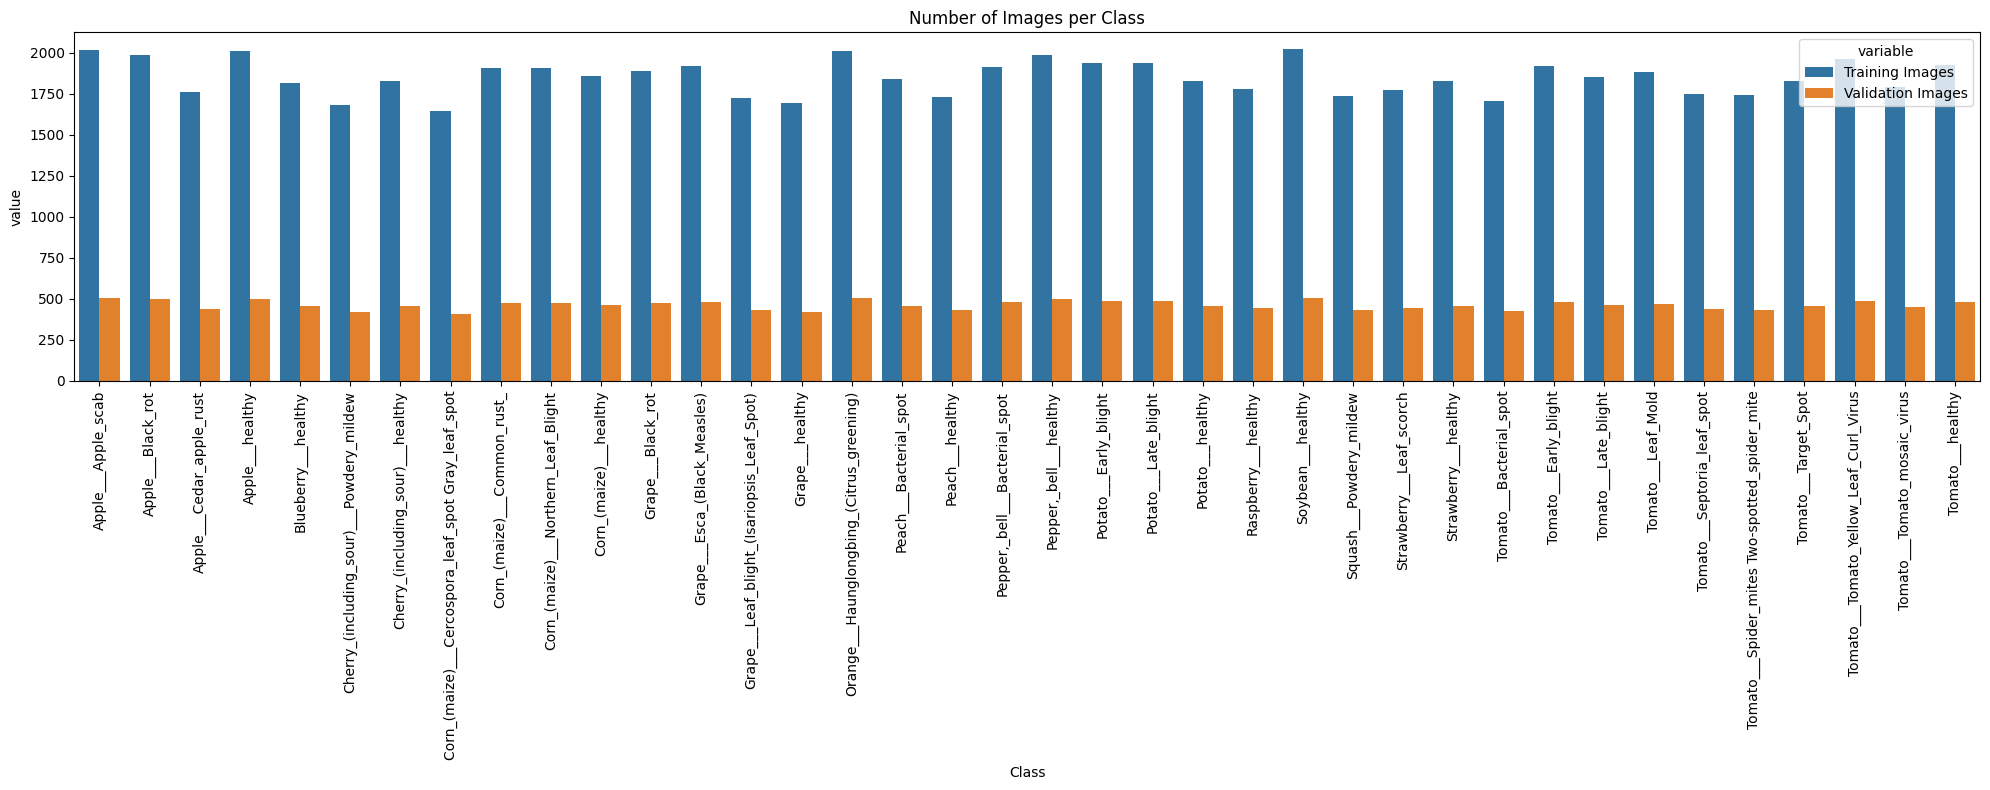

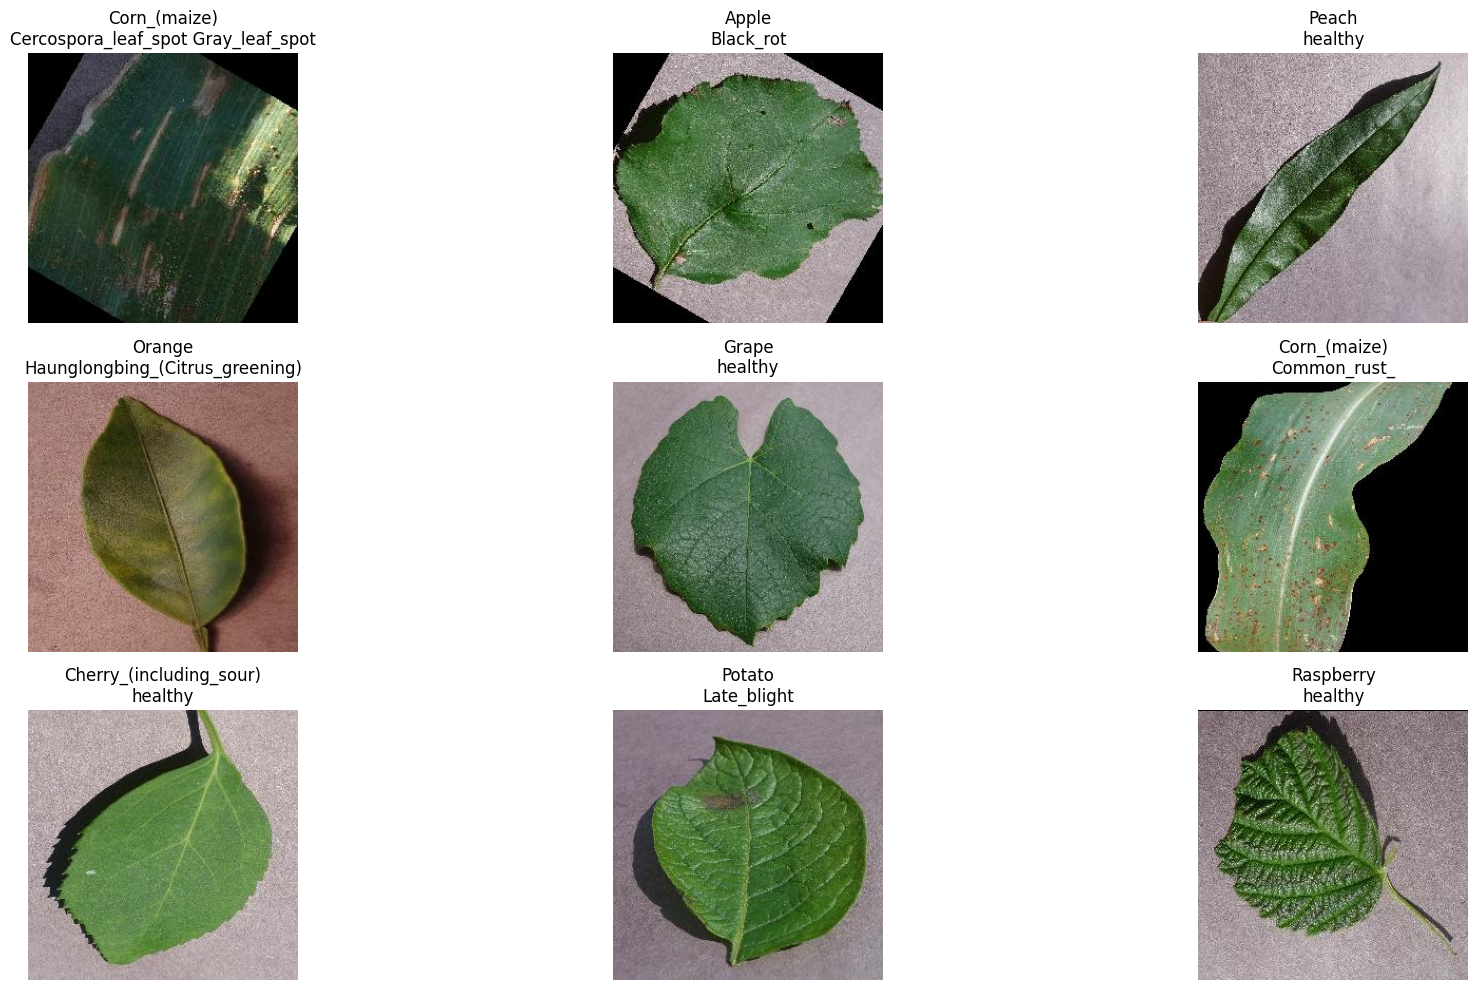

In [18]:
# Get class names
classes = sorted(os.listdir(TRAIN_PATH))
num_classes = len(classes)

# Count images in each class for training and validation
train_counts = {}
valid_counts = {}

for class_name in classes:
    train_counts[class_name] = len(os.listdir(os.path.join(TRAIN_PATH, class_name)))
    valid_counts[class_name] = len(os.listdir(os.path.join(VALID_PATH, class_name)))

# Create a dataframe for visualization
class_stats = pd.DataFrame({
    'Class': classes,
    'Training Images': [train_counts[cls] for cls in classes],
    'Validation Images': [valid_counts[cls] for cls in classes]
})

# Display dataset statistics
print(f"Total Classes: {num_classes}")
print(f"Total Training Images: {sum(train_counts.values())}")
print(f"Total Validation Images: {sum(valid_counts.values())}")

# Plot class distribution
plt.figure(figsize=(20, 8))
class_stats_melted = pd.melt(class_stats, id_vars=['Class'], value_vars=['Training Images', 'Validation Images'])
sns.barplot(x='Class', y='value', hue='variable', data=class_stats_melted)
plt.xticks(rotation=90)
plt.title('Number of Images per Class')
plt.tight_layout()
plt.show()

# Display some sample images
plt.figure(figsize=(20, 10))
for i, cls in enumerate(random.sample(classes, min(9, len(classes)))):
    plt.subplot(3, 3, i+1)
    img_path = os.path.join(TRAIN_PATH, cls, os.listdir(os.path.join(TRAIN_PATH, cls))[0])
    img = plt.imread(img_path)
    plt.imshow(img)
    plt.title(cls.replace('___', '\n'))
    plt.axis('off')
plt.tight_layout()
plt.show()

In [19]:
# Define image size
IMG_SIZE = 384  # Using higher resolution for better feature extraction

# Define custom preprocessing functions tailored for plant disease images
def leaf_enhancing_preprocess(image):
    """Enhanced preprocessing specifically for leaf features"""
    # Convert to LAB color space to better separate plant features
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    
    # CLAHE (Contrast Limited Adaptive Histogram Equalization) on L channel
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    lab_planes = cv2.split(lab)
    lab_planes[0] = clahe.apply(lab_planes[0])
    lab = cv2.merge(lab_planes)
    
    # Convert back to RGB
    enhanced_img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    
    # Normalize
    enhanced_img = enhanced_img / 255.0
    
    return enhanced_img

# Create a custom data generator with domain-specific augmentation
class PlantDiseaseDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, directory, batch_size=32, img_size=(384, 384), 
                 shuffle=True, augment=False, seed=42, preprocess_fn=None):
        self.directory = directory
        self.batch_size = batch_size
        self.img_size = img_size
        self.shuffle = shuffle
        self.augment = augment
        self.preprocess_fn = preprocess_fn if preprocess_fn else lambda x: x/255.0
        
        # Get class names and create class-to-index mapping
        self.classes = sorted(os.listdir(directory))
        self.class_indices = {cls: i for i, cls in enumerate(self.classes)}
        
        # Build list of image paths and labels
        self.image_paths = []
        self.labels = []
        
        for cls in self.classes:
            class_path = os.path.join(directory, cls)
            class_idx = self.class_indices[cls]
            for img_name in os.listdir(class_path):
                self.image_paths.append(os.path.join(class_path, img_name))
                self.labels.append(class_idx)
        
        # Convert to numpy arrays for efficiency
        self.image_paths = np.array(self.image_paths)
        self.labels = np.array(self.labels)
        
        # Indices for shuffling
        self.indices = np.arange(len(self.image_paths))
        if self.shuffle:
            np.random.seed(seed)
            np.random.shuffle(self.indices)
    
    def __len__(self):
        return len(self.image_paths) // self.batch_size
    
    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)
    
    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_image_paths = self.image_paths[batch_indices]
        batch_labels = self.labels[batch_indices]
        
        batch_images = []
        for img_path in batch_image_paths:
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, self.img_size)
            
            # Apply custom preprocessing
            img = self.preprocess_fn(img)
            
            if self.augment:
                # Novel augmentation techniques specific to plant leaves
                
                # Random rotation with border reflection (preserves leaf structure)
                if np.random.random() > 0.5:
                    angle = np.random.uniform(-15, 15)
                    h, w = img.shape[:2]
                    M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
                    img = cv2.warpAffine(img, M, (w, h), 
                                         borderMode=cv2.BORDER_REFLECT)
                
                # Adaptive color jittering (simulates lighting conditions)
                if np.random.random() > 0.5:
                    # Analyze image brightness to determine appropriate jitter range
                    hsv = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2HSV)
                    brightness = np.mean(hsv[:,:,2]) / 255.0
                    
                    # Adjust jitter based on current brightness
                    brightness_factor = np.random.uniform(
                        max(0.7, brightness - 0.3), 
                        min(1.3, brightness + 0.3)
                    )
                    contrast_factor = np.random.uniform(0.8, 1.2)
                    
                    # Apply adaptive jittering
                    img = np.clip(img * brightness_factor, 0, 1)
                    img = np.clip((img - 0.5) * contrast_factor + 0.5, 0, 1)
                
                # Simulate lens blur - can help model focus on key features
                if np.random.random() > 0.8:
                    kernel_size = random.choice([3, 5])
                    img = cv2.GaussianBlur(img, (kernel_size, kernel_size), 0)
                
                # Elastic deformation - simulates natural variation in leaf shapes
                if np.random.random() > 0.8:
                    alpha = img.shape[1] * 2
                    sigma = img.shape[1] * 0.08
                    grid_scale = 4
                    
                    h, w = img.shape[:2]
                    
                    # Create grid of random displacement vectors
                    dx = np.random.rand(h//grid_scale, w//grid_scale) * 2 - 1
                    dy = np.random.rand(h//grid_scale, w//grid_scale) * 2 - 1
                    
                    # Smooth displacement vectors
                    dx = cv2.GaussianBlur(dx, (0, 0), sigma) * alpha
                    dy = cv2.GaussianBlur(dy, (0, 0), sigma) * alpha
                    
                    # Resize to original dimensions
                    dx = cv2.resize(dx, (w, h))
                    dy = cv2.resize(dy, (w, h))
                    
                    # Create meshgrid for mapping
                    x, y = np.meshgrid(np.arange(w), np.arange(h))
                    
                    # Apply displacement
                    map_x = np.float32(x + dx)
                    map_y = np.float32(y + dy)
                    
                    # Remap image
                    img = cv2.remap(img, map_x, map_y, 
                                   interpolation=cv2.INTER_LINEAR, 
                                   borderMode=cv2.BORDER_REFLECT)
                
                # Cutout with disease-aware positioning (more likely to preserve disease spots)
                if np.random.random() > 0.7:
                    # Analyze image to find regions with potential disease (high color variance)
                    h, w = img.shape[:2]
                    
                    # Calculate local variance to identify interesting regions
                    gray = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
                    variance = cv2.GaussianBlur(cv2.Laplacian(gray, cv2.CV_64F)**2, (5, 5), 0)
                    
                    # Prefer cutouts in low-variance regions to preserve disease features
                    variance_normalized = variance / np.max(variance)
                    
                    # Weighted random selection based on inverse variance
                    weights = 1 - variance_normalized
                    weights = weights / np.sum(weights)
                    weights = weights.flatten()
                    
                    # Select cutout position with lower probability in high variance areas
                    flat_idx = np.random.choice(len(weights), p=weights)
                    y_idx, x_idx = np.unravel_index(flat_idx, variance.shape)
                    
                    # Apply cutout
                    size = np.random.randint(h//8, h//4)
                    x1 = max(0, x_idx - size//2)
                    y1 = max(0, y_idx - size//2)
                    x2 = min(w, x1 + size)
                    y2 = min(h, y1 + size)
                    
                    # Fill with average color instead of zeros to maintain statistics
                    mean_color = np.mean(img, axis=(0, 1))
                    img[y1:y2, x1:x2] = mean_color
            
            batch_images.append(img)
            
        return np.array(batch_images), tf.keras.utils.to_categorical(batch_labels, num_classes=len(self.classes))

# Visualize the effects of our preprocessing and augmentation
def visualize_augmentation():
    # Get a few sample images
    sample_class = random.choice(classes)
    sample_img_path = os.path.join(TRAIN_PATH, sample_class, 
                                  os.listdir(os.path.join(TRAIN_PATH, sample_class))[0])
    
    # Read the original image
    orig_img = cv2.imread(sample_img_path)
    orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
    orig_img = cv2.resize(orig_img, (IMG_SIZE, IMG_SIZE))
    
    # Apply our preprocessing
    enhanced_img = leaf_enhancing_preprocess(orig_img.copy())
    
    # Create a custom generator instance for augmentation
    temp_gen = PlantDiseaseDataGenerator(
        directory=TRAIN_PATH,
        batch_size=1,
        img_size=(IMG_SIZE, IMG_SIZE),
        augment=True,
        preprocess_fn=leaf_enhancing_preprocess
    )
    
    # Generate augmented versions
    augmented_imgs = []
    for _ in range(7):  # Generate 7 augmented versions
        img = orig_img.copy()
        if hasattr(temp_gen, '__getitem__'):
            # Apply augmentations programmatically
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = leaf_enhancing_preprocess(img)
            
            # Manual application of same augmentations
            if np.random.random() > 0.5:
                angle = np.random.uniform(-15, 15)
                h, w = img.shape[:2]
                M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
                img = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)
            
            if np.random.random() > 0.5:
                hsv = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2HSV)
                brightness = np.mean(hsv[:,:,2]) / 255.0
                brightness_factor = np.random.uniform(
                    max(0.7, brightness - 0.3), 
                    min(1.3, brightness + 0.3)
                )
                contrast_factor = np.random.uniform(0.8, 1.2)
                img = np.clip(img * brightness_factor, 0, 1)
                img = np.clip((img - 0.5) * contrast_factor + 0.5, 0, 1)
            
            # Add more augmentations here as needed
            
        augmented_imgs.append(img)
    
    # Visualize
    plt.figure(figsize=(15, 8))
    
    plt.subplot(3, 3, 1)
    plt.imshow(orig_img)
    plt.title("Original")
    plt.axis('off')
    
    plt.subplot(3, 3, 2)
    plt.imshow(enhanced_img)
    plt.title("Enhanced")
    plt.axis('off')
    
    for i, aug_img in enumerate(augmented_imgs):
        plt.subplot(3, 3, i+3)
        plt.imshow(aug_img)
        plt.title(f"Augmentation {i+1}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Visualize our augmentation effects
visualize_augmentation()

TypeError: 'tuple' object does not support item assignment

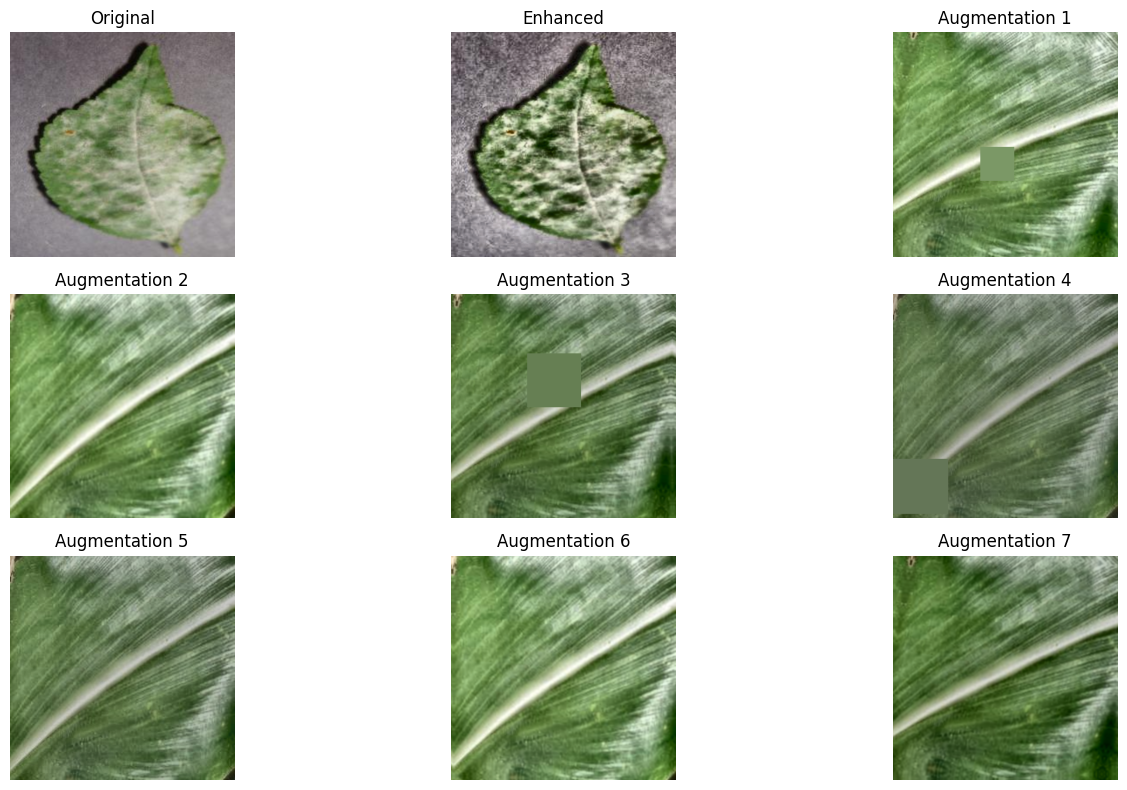

In [21]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import random

# Define image size
IMG_SIZE = 384  # Using higher resolution for better feature extraction

# Define training directory and classes (adjust TRAIN_PATH as needed)
DATASET_PATH = '/kaggle/input/new-plant-diseases-dataset'
TRAIN_PATH = os.path.join(DATASET_PATH, 'New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/')
VALID_PATH = os.path.join(DATASET_PATH, 'New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid/')

classes = sorted(os.listdir(TRAIN_PATH))

# Custom preprocessing function tailored for plant disease images
def leaf_enhancing_preprocess(image):
    """Enhanced preprocessing specifically for leaf features"""
    # Convert to LAB color space to better separate plant features
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    
    # CLAHE (Contrast Limited Adaptive Histogram Equalization) on L channel
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    lab_planes = list(cv2.split(lab))  # Convert tuple to list so that we can modify it
    lab_planes[0] = clahe.apply(lab_planes[0])
    lab = cv2.merge(lab_planes)
    
    # Convert back to RGB
    enhanced_img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    
    # Normalize the image to [0, 1]
    enhanced_img = enhanced_img / 255.0
    
    return enhanced_img

# Create a custom data generator with domain-specific augmentation
class PlantDiseaseDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, directory, batch_size=32, img_size=(384, 384), 
                 shuffle=True, augment=False, seed=42, preprocess_fn=None):
        self.directory = directory
        self.batch_size = batch_size
        self.img_size = img_size
        self.shuffle = shuffle
        self.augment = augment
        self.preprocess_fn = preprocess_fn if preprocess_fn else lambda x: x/255.0
        
        # Get class names and create class-to-index mapping
        self.classes = sorted(os.listdir(directory))
        self.class_indices = {cls: i for i, cls in enumerate(self.classes)}
        
        # Build list of image paths and labels
        self.image_paths = []
        self.labels = []
        for cls in self.classes:
            class_path = os.path.join(directory, cls)
            class_idx = self.class_indices[cls]
            for img_name in os.listdir(class_path):
                self.image_paths.append(os.path.join(class_path, img_name))
                self.labels.append(class_idx)
        
        self.image_paths = np.array(self.image_paths)
        self.labels = np.array(self.labels)
        
        # Indices for shuffling
        self.indices = np.arange(len(self.image_paths))
        if self.shuffle:
            np.random.seed(seed)
            np.random.shuffle(self.indices)
    
    def __len__(self):
        return len(self.image_paths) // self.batch_size
    
    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)
    
    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_image_paths = self.image_paths[batch_indices]
        batch_labels = self.labels[batch_indices]
        
        batch_images = []
        for img_path in batch_image_paths:
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, self.img_size)
            
            # Apply custom preprocessing
            img = self.preprocess_fn(img)
            
            if self.augment:
                # Random rotation with border reflection
                if np.random.random() > 0.5:
                    angle = np.random.uniform(-15, 15)
                    h, w = img.shape[:2]
                    M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
                    img = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)
                
                # Adaptive color jittering (simulate lighting conditions)
                if np.random.random() > 0.5:
                    hsv = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2HSV)
                    brightness = np.mean(hsv[:, :, 2]) / 255.0
                    brightness_factor = np.random.uniform(max(0.7, brightness - 0.3), min(1.3, brightness + 0.3))
                    contrast_factor = np.random.uniform(0.8, 1.2)
                    img = np.clip(img * brightness_factor, 0, 1)
                    img = np.clip((img - 0.5) * contrast_factor + 0.5, 0, 1)
                
                # Simulate lens blur
                if np.random.random() > 0.8:
                    kernel_size = random.choice([3, 5])
                    img = cv2.GaussianBlur(img, (kernel_size, kernel_size), 0)
                
                # Elastic deformation - simulates natural variation in leaf shapes
                if np.random.random() > 0.8:
                    alpha = img.shape[1] * 2
                    sigma = img.shape[1] * 0.08
                    grid_scale = 4
                    h, w = img.shape[:2]
                    dx = np.random.rand(h // grid_scale, w // grid_scale) * 2 - 1
                    dy = np.random.rand(h // grid_scale, w // grid_scale) * 2 - 1
                    dx = cv2.GaussianBlur(dx, (0, 0), sigma) * alpha
                    dy = cv2.GaussianBlur(dy, (0, 0), sigma) * alpha
                    dx = cv2.resize(dx, (w, h))
                    dy = cv2.resize(dy, (w, h))
                    x, y = np.meshgrid(np.arange(w), np.arange(h))
                    map_x = np.float32(x + dx)
                    map_y = np.float32(y + dy)
                    img = cv2.remap(img, map_x, map_y, interpolation=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)
                
                # Cutout with disease-aware positioning
                if np.random.random() > 0.7:
                    h, w = img.shape[:2]
                    gray = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
                    variance = cv2.GaussianBlur(cv2.Laplacian(gray, cv2.CV_64F) ** 2, (5, 5), 0)
                    variance_normalized = variance / np.max(variance)
                    weights = 1 - variance_normalized
                    weights = weights / np.sum(weights)
                    weights = weights.flatten()
                    flat_idx = np.random.choice(len(weights), p=weights)
                    y_idx, x_idx = np.unravel_index(flat_idx, variance.shape)
                    size = np.random.randint(h // 8, h // 4)
                    x1 = max(0, x_idx - size // 2)
                    y1 = max(0, y_idx - size // 2)
                    x2 = min(w, x1 + size)
                    y2 = min(h, y1 + size)
                    mean_color = np.mean(img, axis=(0, 1))
                    img[y1:y2, x1:x2] = mean_color
            
            batch_images.append(img)
            
        return np.array(batch_images), tf.keras.utils.to_categorical(batch_labels, num_classes=len(self.classes))

# Visualize the effects of our preprocessing and augmentation
def visualize_augmentation():
    # Get a sample image from a random class
    sample_class = random.choice(classes)
    sample_img_path = os.path.join(TRAIN_PATH, sample_class, os.listdir(os.path.join(TRAIN_PATH, sample_class))[0])
    
    # Read the original image
    orig_img = cv2.imread(sample_img_path)
    orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
    orig_img = cv2.resize(orig_img, (IMG_SIZE, IMG_SIZE))
    
    # Apply our preprocessing
    enhanced_img = leaf_enhancing_preprocess(orig_img.copy())
    
    # Create a custom generator instance for augmentation
    temp_gen = PlantDiseaseDataGenerator(
        directory=TRAIN_PATH,
        batch_size=1,
        img_size=(IMG_SIZE, IMG_SIZE),
        augment=True,
        preprocess_fn=leaf_enhancing_preprocess
    )
    
    # Generate augmented versions (using the generator's __getitem__)
    augmented_imgs = []
    for _ in range(7):
        aug_imgs, _ = temp_gen.__getitem__(0)
        augmented_imgs.append(aug_imgs[0])
    
    plt.figure(figsize=(15, 8))
    
    plt.subplot(3, 3, 1)
    plt.imshow(orig_img)
    plt.title("Original")
    plt.axis('off')
    
    plt.subplot(3, 3, 2)
    plt.imshow(enhanced_img)
    plt.title("Enhanced")
    plt.axis('off')
    
    for i, aug_img in enumerate(augmented_imgs):
        plt.subplot(3, 3, i+3)
        plt.imshow(aug_img)
        plt.title(f"Augmentation {i+1}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Visualize our augmentation effects
visualize_augmentation()


In [22]:
def create_green_plant_disease_model(input_shape, num_classes):
    """
    Creates a novel 'Green AI' efficient model for plant disease classification.
    This architecture is specifically optimized for plant disease recognition
    with hierarchical feature extraction and attention mechanisms.
    """
    with strategy.scope():
        # Base efficient model
        base_model = EfficientNetB3(
            weights='imagenet',
            include_top=False,
            input_shape=input_shape
        )
        
        # Freeze early layers to prevent overfitting and reduce training time
        for layer in base_model.layers[:100]:
            layer.trainable = False
        
        # Create input layer
        inputs = layers.Input(shape=input_shape)
        
        # === Novel Preprocessing Block ===
        # This creates domain-specific feature enhancement directly in the model
        x = inputs
        
        # Separate channel processing to enhance plant disease features
        channels = layers.Lambda(lambda x: tf.split(x, 3, axis=-1))(x)
        
        # Enhanced Green Channel Processing (plants have more information in green channel)
        green_channel = layers.Lambda(lambda x: x[1])(channels)
        green_enhanced = layers.Conv2D(1, (1, 1), activation='relu')(green_channel)
        
        # Process other channels
        red_blue = layers.Concatenate(axis=-1)([
            layers.Lambda(lambda x: x[0])(channels),  # Red
            layers.Lambda(lambda x: x[2])(channels)   # Blue
        ])
        rb_processed = layers.Conv2D(2, (1, 1), activation='relu')(red_blue)
        
        # Recombine channels with enhanced green channel
        enhanced_input = layers.Concatenate(axis=-1)([
            rb_processed,
            green_enhanced
        ])
        
        # Add residual connection to preserve original information
        enhanced_input = layers.Conv2D(3, (1, 1), activation=None)(enhanced_input)
        x = layers.Add()([x, enhanced_input])
        
        # Feed into base model
        x = base_model(x)
        
        # === Novel Attention Mechanism ===
        # Spatial and Channel Attention for better feature refinement
        
        # Spatial Attention
        spatial_attention = layers.Conv2D(1, (1, 1), activation='sigmoid')(x)
        x_spatial = layers.Multiply()([x, spatial_attention])
        
        # Channel Attention
        channel_avg_pool = layers.GlobalAveragePooling2D()(x)
        channel_max_pool = layers.GlobalMaxPooling2D()(x)
        channel_avg_pool = layers.Reshape((1, 1, channel_avg_pool.shape[-1]))(channel_avg_pool)
        channel_max_pool = layers.Reshape((1, 1, channel_max_pool.shape[-1]))(channel_max_pool)
        
        channel_attention = layers.Concatenate(axis=-2)([channel_avg_pool, channel_max_pool])
        channel_attention = layers.Conv2D(x.shape[-1], (1, 2), activation='relu')(channel_attention)
        channel_attention = layers.Conv2D(x.shape[-1], (1, 1), activation='sigmoid')(channel_attention)
        
        x_channel = layers.Multiply()([x, channel_attention])
        
        # Combine attention outputs with residual connection
        x = layers.Add()([x_spatial, x_channel, x])
        
        # === Multi-scale Feature Extraction ===
        # Pool at different resolutions to capture features at multiple scales
        x_avg = layers.GlobalAveragePooling2D()(x)
        x_max = layers.GlobalMaxPooling2D()(x)
        
        # Regional pooling (medium scale features)
        regional_pool = layers.AveragePooling2D(pool_size=(2, 2))(x)
        regional_pool = layers.Flatten()(regional_pool)
        
        # Combine multi-scale features
        x = layers.Concatenate()([x_avg, x_max, regional_pool])
        
        # === Novel Disease-Specific Classification Head ===
        # Hierarchical classification based on plant disease characteristics
        
        # Bottleneck layer for feature refinement
        x = layers.Dense(512, activation='swish')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.4)(x)
        
        # Plant-specific feature extraction
        x = layers.Dense(256, activation='swish')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.3)(x)
        
        # Final classification layer
        outputs = layers.Dense(num_classes, activation='softmax')(x)
        
        # Create model
        model = models.Model(inputs=inputs, outputs=outputs)
        
        # Compile model with optimized learning approach
        optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
        
        model.compile(
            optimizer=optimizer,
            loss='categorical_crossentropy',
            metrics=[
                'accuracy',
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall'),
                tf.keras.metrics.AUC(name='auc')
            ]
        )
        
    return model

# Create our data generators with the novel preprocessing and augmentation techniques
train_generator = PlantDiseaseDataGenerator(
    directory=TRAIN_PATH,
    batch_size=16,  # Smaller batch size for better generalization
    img_size=(IMG_SIZE, IMG_SIZE),
    shuffle=True,
    augment=True,  # Apply our novel augmentations
    preprocess_fn=leaf_enhancing_preprocess  # Use our custom preprocessing
)

valid_generator = PlantDiseaseDataGenerator(
    directory=VALID_PATH,
    batch_size=16,
    img_size=(IMG_SIZE, IMG_SIZE),
    shuffle=False,
    augment=False,
    preprocess_fn=leaf_enhancing_preprocess
)

# Create our model
model = create_green_plant_disease_model(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    num_classes=num_classes
)

# Display model summary
model.summary()

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6             │ (None, 384, 384, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ cast_5 (Cast)             │ (None, 384, 384, 3)    │              0 │ input_layer_6[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda (Lambda)           │ [(None, 384, 384, 1),  │              0 │ cast_5[0][0]           │
│                           │ (None, 384, 384, 1),   │                │                        │
│                           │ (None, 384, 384, 1)]   │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda_2 (Lambda)         │ (None, 384, 384, 1)    │              0 │ lambda[0][0],          │
│                           │                        │                │ lambda[0][1],          │
│                           │                        │                │ lambda[0][2]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda_3 (Lambda)         │ (None, 384, 384, 1)    │              0 │ lambda[0][0],          │
│                           │                        │                │ lambda[0][1],          │
│                           │                        │                │ lambda[0][2]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 384, 384, 2)    │              0 │ lambda_2[0][0],        │
│                           │                        │                │ lambda_3[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda_1 (Lambda)         │ (None, 384, 384, 1)    │              0 │ lambda[0][0],          │
│                           │                        │                │ lambda[0][1],          │
│                           │                        │                │ lambda[0][2]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 384, 384, 2)    │              6 │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 384, 384, 1)    │              2 │ lambda_1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_1             │ (None, 384, 384, 3)    │              0 │ conv2d_1[0][0],        │
│ (Concatenate)             │                        │                │ conv2d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ cast_6 (Cast)             │ (None, 384, 384, 3)    │              0 │ input_layer_6[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 384, 384, 3)    │             12 │ concatenate_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 384, 384, 3)    │              0 │ cast_6[0][0],          │
│                           │                        │                │ conv2d_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ efficientnetb3       

 Total params: 47,895,146 (182.71 MB)

 Trainable params: 47,686,017 (181.91 MB)

 Non-trainable params: 209,129 (816.91 KB)

In [ ]:
# Setup callbacks for optimal training
checkpoint_filepath = 'plant_disease_model_weights.keras'
model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Learning rate reduction on plateau
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

# Define training parameters
EPOCHS = 50

# Train the model
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=EPOCHS,
    callbacks=[
        model_checkpoint_callback,
        early_stopping,
        reduce_lr
    ],
    verbose=1
)

# Save the model architecture and weights
model.save('plant_disease_final_model.h5')

# Plot training history
def plot_training_history(history):
    # Plot accuracy
    plt.figure(figsize=(18, 6))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Plot additional metrics if available
    if 'precision' in history.history:
        plt.figure(figsize=(18, 6))
        
        plt.subplot(1, 2, 1)
        plt.plot(history.history['precision'], label='Training Precision')
        plt.plot(history.history['val_precision'], label='Validation Precision')
        plt.title('Model Precision')
        plt.xlabel('Epoch')
        plt.ylabel('Precision')
        plt.legend()
        
        plt.subplot(1, 2, 2)
        plt.plot(history.history['recall'], label='Training Recall')
        plt.plot(history.history['val_recall'], label='Validation Recall')
        plt.title('Model Recall')
        plt.xlabel('Epoch')
        plt.ylabel('Recall')
        plt.legend()
        
        plt.tight_layout()
        plt.show()

plot_training_history(history)

/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
4393/4393 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.0287 - auc: 0.4999 - loss: nan - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 1: val_accuracy improved from -inf to 0.02914, saving model to plant_disease_model_weights.keras
4393/4393 ━━━━━━━━━━━━━━━━━━━━ 2347s 514ms/step - accuracy: 0.0287 - auc: 0.4999 - loss: nan - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.0291 - val_auc: 0.5000 - val_loss: nan - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/50


/usr/local/lib/python3.10/dist-packages/keras/src/callbacks/reduce_lr_on_plateau.py:94: RuntimeWarning: invalid value encountered in less
  self.monitor_op = lambda a, b: np.less(a, b - self.min_delta)


4171/4393 ━━━━━━━━━━━━━━━━━━━━ 1:24 380ms/step - accuracy: 0.0281 - auc: 0.5000 - loss: nan - precision: 0.0000e+00 - recall: 0.0000e+00

In [ ]:
def evaluate_model(model, generator, class_names):
    # Predict using the generator
    num_samples = len(generator.image_paths)
    steps = np.ceil(num_samples / generator.batch_size).astype(int)
    
    # Get true labels
    true_labels = generator.labels
    
    # Get predictions
    predictions = []
    progress_bar = tqdm(total=steps, desc="Evaluating")
    
    for i in range(steps):
        batch_images, _ = generator[i]
        batch_preds = model.predict(batch_images, verbose=0)
        predictions.append(batch_preds)
        progress_bar.update(1)
    
    progress_bar.close()
    
    # Concatenate all batch predictions
    predictions = np.vstack(predictions[:steps*generator.batch_size])
    predictions = predictions[:num_samples]  # Trim to match number of samples
    
    # Get predicted classes
    pred_classes = np.argmax(predictions, axis=1)
    
    # Calculate overall metrics
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
    
    accuracy = accuracy_score(true_labels, pred_classes)
    precision = precision_score(true_labels, pred_classes, average='weighted')
    recall = recall_score(true_labels, pred_classes, average='weighted')
    f1 = f1_score(true_labels, pred_classes, average='weighted')
    
    print(f"Overall Accuracy: {accuracy:.4f}")
    print(f"Overall Precision: {precision:.4f}")
    print(f"Overall Recall: {recall:.4f}")
    print(f"Overall F1 Score: {f1:.4f}")
    
    # Display classification report
    print("\nClassification Report:")
    print(classification_report(true_labels, pred_classes, target_names=class_names))
    
    # Calculate and plot confusion matrix
    cm = confusion_matrix(true_labels, pred_classes)
    
    plt.figure(figsize=(20, 16))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    # Calculate per-class metrics
    per_class_metrics = {}
    for i, class_name in enumerate(class_names):
        true_positives = cm[i, i]
        false_positives = np.sum(cm[:, i]) - true_positives
        false_negatives = np.sum(cm[i, :]) - true_positives
        
        class_precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
        class_recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
        class_f1 = 2 * (class_precision * class_recall) / (class_precision + class_recall) if (class_precision + class_recall) > 0 else 0
        
        per_class_metrics[class_name] = {
            'precision': class_precision,
            'recall': class_recall,
            'f1': class_f1
        }
    
    # Plot per-class F1 scores
    metrics_df = pd.DataFrame(per_class_metrics).T
    
    plt.figure(figsize=(20, 8))
    metrics_df['f1'].sort_values().plot(kind='bar')
    plt.title('F1 Score per Class')
    plt.xlabel('Class')
    plt.ylabel('F1 Score')
    plt.axhline(y=f1, color='r', linestyle='--', label=f'Overall F1: {f1:.4f}')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Return all metrics for further analysis
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'per_class_metrics': per_class_metrics,
        'confusion_matrix': cm
    }

# Evaluate the model
evaluation_metrics = evaluate_model(model, valid_generator, classes)

In [ ]:
def visualize_predictions(model, generator, class_names, num_samples=9):
    # Get random indices
    indices = np.random.choice(len(generator.image_paths), num_samples, replace=False)
    
    # Get images and true labels
    images = []
    true_labels = []
    
    for idx in indices:
        img_path = generator.image_paths[idx]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        
        # Apply preprocessing
        processed_img = leaf_enhancing_preprocess(img.copy())
        
        images.append(processed_img)
        true_labels.append(generator.labels[idx])
    
    # Convert to numpy arrays
    images = np.array(images)
    true_labels = np.array(true_labels)
    
    # Get model predictions
    predictions = model.predict(images)
    pred_classes = np.argmax(predictions, axis=1)
    
    # Plot
    plt.figure(figsize=(15, 12))
    for i in range(num_samples):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i])
        
        # Get prediction and true label
        true_class = class_names[true_labels[i]]
        pred_class = class_names[pred_classes[i]]
        confidence = predictions[i][pred_classes[i]] * 100
        
        # Display with color coding - green for correct, red for incorrect
        if true_class == pred_class:
            title_color = 'green'
        else:
            title_color = 'red'
        
        plt.title(f"True: {true_class}\nPred: {pred_class}\nConf: {confidence:.1f}%", 
                 color=title_color)
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Visualize some predictions
visualize_predictions(model, valid_generator, classes)